In [96]:
import pandas as pd

df = pd.read_csv(r"D:\spotify_project\dataset.csv")

print(df.shape)
df.head()

(114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [97]:
df = df.drop(columns=[
    "Unnamed: 0",
    "track_id",
    "artists",
    "album_name",
    "track_name"
])

df.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [98]:
df["track_genre"].nunique()
df.duplicated().sum()
df.isnull().sum()


popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [99]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["track_genre_encoded"] = le.fit_transform(df["track_genre"])

In [100]:
X = df.drop(columns=["track_genre", "track_genre_encoded"])

# keep only numeric columns
X = X.select_dtypes(include=["int64", "float64", "bool"])

In [101]:
X = X.astype(int, errors="ignore")

In [102]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [103]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [106]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [80]:
y_pred = rf.predict(X_test)

IndexError: list index out of range

In [92]:
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

popularity      0.0
duration_ms     0.0
explicit        0.0
danceability    0.0
energy          0.0
key             0.0
loudness        0.0
mode            0.0
speechiness     0.0
acousticness    0.0
dtype: float64

In [77]:
X_rf = X.values  # unscaled features

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X_rf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [94]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

MemoryError: could not allocate 3735552 bytes

In [ ]:
y_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

In [107]:
top_genres = df['track_genre'].value_counts().nlargest(20).index

df['genre_grouped'] = df['track_genre'].apply(
    lambda x: x if x in top_genres else 'other'
)

In [108]:
df[['track_genre', 'genre_grouped']].head()

,track_genre,genre_grouped
0,acoustic,acoustic
1,acoustic,acoustic
2,acoustic,acoustic
3,acoustic,acoustic
4,acoustic,acoustic


In [109]:
df['genre_grouped'].nunique()

21

In [110]:
y = df['genre_grouped']

In [111]:
from sklearn.model_selection import train_test_split

X_rf = X.values  # X = numeric features you already created

X_train, X_test, y_train, y_test = train_test_split(
    X_rf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [119]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,25
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [120]:
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

               precision    recall  f1-score   support

     acoustic       0.20      0.04      0.07       200
     afrobeat       0.26      0.10      0.14       200
     alt-rock       0.06      0.08      0.07       200
  alternative       0.10      0.14      0.12       200
      ambient       0.24      0.14      0.17       200
        anime       0.01      0.01      0.01       200
  black-metal       0.30      0.11      0.16       200
    bluegrass       0.23      0.14      0.17       200
        blues       0.21      0.25      0.23       200
       brazil       0.04      0.03      0.03       200
    breakbeat       0.50      0.27      0.35       200
      british       0.08      0.04      0.05       200
     cantopop       0.06      0.01      0.02       200
chicago-house       0.44      0.47      0.46       200
     children       0.50      0.19      0.28       200
        chill       0.13      0.07      0.09       200
    classical       0.51      0.47      0.49       200
         

In [122]:
from sklearn.metrics import f1_score

print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred, average="weighted"))

Macro F1: 0.2331242925101451
Weighted F1: 0.7678253734907912


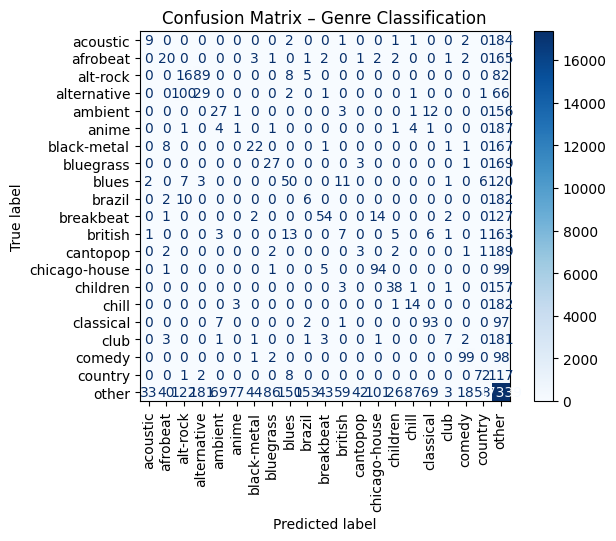

In [123]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    xticks_rotation=90,
    cmap='Blues'
)

plt.title("Confusion Matrix – Genre Classification")
plt.show()